# Controle de Processos - COQ792 - EQE 768
Rafael Ferreira Cavalcante

rcavalcante@peq.coppe.ufrj.br

Este notebook apresenta o controle MPC aplicado a coluna de destilação binária de [Wood & Berry, 1973](https://www.sciencedirect.com/science/article/abs/pii/0009250973800259).

### Introdução

A coluna de destilação proposta por Wood & Berry é um *benchmark* clássico de controle MIMO. É definida como uma coluna para a separação de uma mistura binária methanol-água, com 2 variáveis controladas e 2 variáveis manipuladas.



<p align="center">
  <img src="wood_berry_draft.svg" width="750">
</p>

#### Problema de Controle

  O problema de controle é definido por 2 variáveis manipuladas, o refluxo de líquido para dentro da coluna $L$, e a vazão de vapor para o refervedor $V$. As variáveis controladas são, a composição do produto de topo $x_D$ (fração molar de metanol no destilado), e a composição do produto de fundo $x_B$ (fração molar de metanol no produto de fundo)

  Definindo as variáveis do problema de controle como,

  $$
  x_D → y_1 \\
  x_B → y_2 \\
  L → u_1 \\
  V → u_2
  $$

  Em forma matricial o problema de controle pode ser definido como,

  $$
  \begin{bmatrix}
    x_D \\
    x_B
    \end{bmatrix} = G(s) \begin{bmatrix}
    L \\
    V
  \end{bmatrix}
  $$

  Onde $G(s)$ é a matriz de funções de transferência do problema.

  Conforme descrito no [artigo de referência](https://www.sciencedirect.com/science/article/abs/pii/0009250973800259), a matriz de funções de transferência é dada por,

  $$
  G(s)=
\begin{bmatrix}
\dfrac{12.8e^{-s}}{16.7s+1} &
\dfrac{-18.9e^{-3s}}{21.0s+1}
\\[1.2em]
\dfrac{6.6e^{-7s}}{10.9s+1} &
\dfrac{-19.4e^{-3s}}{14.4s+1}
\end{bmatrix}
  $$

  Precisamos agora construir um sistema de controle preditivo para o controle da coluna de destilação.

### 1. Realizar o teste ao degrau para a coluna de destilação

Aqui vamos utilizar a coluna de Wood & Berry definida como uma planta rodando em tempo discreto no código ``MIMOsys.py``. Vamos usar usar também as bibliotecas ``Numpy`` e ``Matplotlib`` para álgebra e construção de gráficos respectivamente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.MIMOsys import Wood_Berry

Degrau em $u_1$

In [2]:
Plant = Wood_Berry()

N_STEPS = 120

t = np.zeros(N_STEPS)
y_history = np.zeros((N_STEPS, 2))
u_history = np.zeros((N_STEPS, 2))

DT = 1.0
Y = []

# ----- Loop de simulação ----- #
for k in range(N_STEPS):
    
    u_k = [1.0, 0.0]

    y_meas = Plant.step(u_k)
    
    y_history[k, :] = y_meas
    u_history[k, :] = u_k
    t[k] = k * DT

Y.append(y_history.T[0])
Y.append(y_history.T[1])

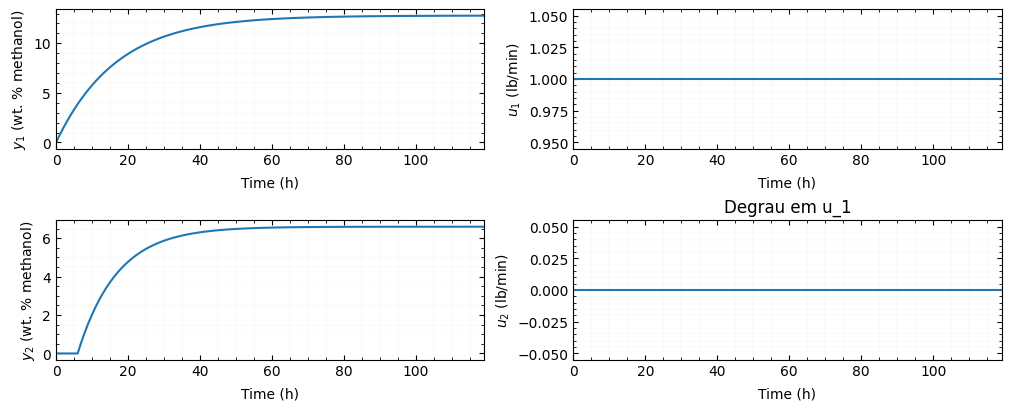

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(10, 4), constrained_layout=True)

ax[0, 0].plot(t, y_history.T[0])
ax[1, 0].plot(t, y_history.T[1])

ax[0, 1].step(t, u_history.T[0])
ax[1, 1].step(t, u_history.T[1])

for a in ax.flatten():
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    a.autoscale(enable=True, axis='x', tight=True)
    
    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()
    a.set_xlabel('Time (h)', labelpad=6.0)

axis_labels = [
    '$y_1$ (wt. % methanol)', 
    '$y_2$ (wt. % methanol)',
    '$u_1$ (lb/min)',
    '$u_2$ (lb/min)'
    ]

for i, a in enumerate(ax.transpose().flatten()):
    a.set_ylabel(axis_labels[i])

plt.title("Degrau em u_1")
plt.show()

Degrau em $u_2$

In [4]:
Plant = Wood_Berry()

N_STEPS = 120

t = np.zeros(N_STEPS)
y_history = np.zeros((N_STEPS, 2))
u_history = np.zeros((N_STEPS, 2))

# ----- Loop de simulação ----- #
for k in range(N_STEPS):
    
    u_k = [0.0, 1.0]

    y_meas = Plant.step(u_k)
    
    y_history[k, :] = y_meas
    u_history[k, :] = u_k
    t[k] = k * DT

Y.append(y_history.T[0])
Y.append(y_history.T[1])

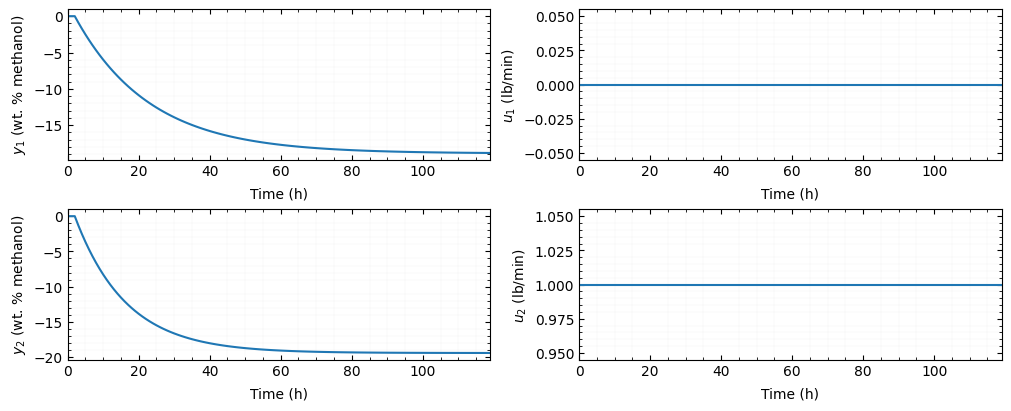

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(10, 4), constrained_layout=True)

ax[0, 0].plot(t, y_history.T[0])
ax[1, 0].plot(t, y_history.T[1])

ax[0, 1].step(t, u_history.T[0])
ax[1, 1].step(t, u_history.T[1])

for a in ax.flatten():
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    a.autoscale(enable=True, axis='x', tight=True)
    
    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()
    a.set_xlabel('Time (h)', labelpad=6.0)

axis_labels = [
    '$y_1$ (wt. % methanol)', 
    '$y_2$ (wt. % methanol)',
    '$u_1$ (lb/min)',
    '$u_2$ (lb/min)'
    ]

for i, a in enumerate(ax.transpose().flatten()):
    a.set_ylabel(axis_labels[i])

plt.show()

Exportar os resultados do teste ao degrau

In [6]:
np.savez(r"results\step_wood_berry.npz", Y=Y, du=[1.0, 1.0])

### Agora vamos criar o modelo de resposta ao degrau e o controlador

O controlador QDMC está definido no arquivo ``controllers.py``, o modelo de resposta ao degrau está definido em ``models.py`` e a parte da otimização está definida em ``optimize.py``.

In [7]:
from src.models import DynamicMatrix, StepResponseModel, FeedbackState
from src.controllers import QDMC
from src.utils import Logger

Geração do modelo de resposta ao degrau

In [8]:
WB_step = np.load(r"results\step_wood_berry.npz")

Y = WB_step['Y']
du = WB_step['du']

Np = 80
Nc = 1

DynMatrix = DynamicMatrix(Np=Np, Nc=Nc, y=Y, step_amp=du)
model = StepResponseModel(DynMatrix)

Geração do controlador e da sintonia

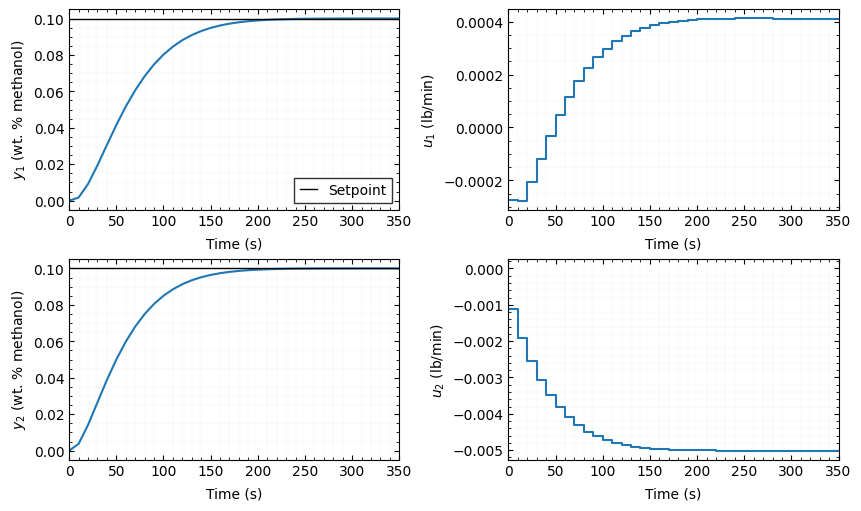

In [9]:
Q = np.array([
    [0.9, 0.0],
    [0.0, 1.0]
    ])

R = np.array([
    [1.0, 0.0],
    [0.0, 1.0]
    ]) * 6e5

controller = QDMC(model=model, Q=Q, R=R, logger=Logger())

Plant = Wood_Berry()


N_STEPS = 360
u_k = np.array([0.0, 0.0])
y_meas = np.array([0.0, 0.0])

y_sp = np.array([0.1, 0.1])

# ----- Simulação de controle em malha fechada ----- #
for k in range(N_STEPS):
    
    # calcula o incremento
    move = controller(y_sp=y_sp, y_meas=y_meas, u_meas=u_k)[0]
    
    # Atualiza as ações manipuladas (Válvulas de vapor/refluxo no caso do Wood & Berry)
    u_k += move
    
    # Propaga a planta um passo a frente
    y_meas = Plant.step(u_k)

# ----- Geração do log de resultados ----- #       
log = controller.logger.to_numpy()
log_y = log['y_meas']
log_u = log['u_meas']
log_sp = log['y_sp']

t = log['k'] * DT

# ----- Criação dos gráficos ----- #   
fig, ax = plt.subplots(2, 2, figsize=(8.5, 5), constrained_layout=True)

t0 = 0
t1 = -1
dt = 10

ax[0, 0].plot(t[t0:t1:dt], log_y.T[0][t0:t1:dt])
ax[1, 0].plot(t[t0:t1:dt], log_y.T[1][t0:t1:dt])

ax[0, 0].plot(t[t0:t1:dt], log_sp.T[0][t0:t1:dt], color='k', ls='-', lw=1.0, label="Setpoint")
ax[1, 0].plot(t[t0:t1:dt], log_sp.T[0][t0:t1:dt], color='k', ls='-', lw=1.0)

ax[0, 1].step(t[t0:t1:dt], log_u.T[0][t0:t1:dt])
ax[1, 1].step(t[t0:t1:dt], log_u.T[1][t0:t1:dt])

for a in ax.flatten():
    a.tick_params(axis='both', which='both',direction='in', top=True, right=True)
    a.autoscale(enable=True, axis='x', tight=True)
    
    a.grid(True, which='minor', linestyle='-', linewidth=0.25, alpha=0.15)
    a.minorticks_on()
    a.set_xlabel('Time (s)', labelpad=6.0)

axis_labels = [
    '$y_1$ (wt. % methanol)', 
    '$y_2$ (wt. % methanol)',
    '$u_1$ (lb/min)',
    '$u_2$ (lb/min)'
    ]

for i, a in enumerate(ax.transpose().flatten()):
    a.set_ylabel(axis_labels[i])

ax[0, 0].legend(
    loc=4,
    ncol = 4,
    frameon = True,
    shadow = False,
    edgecolor= 'k',
    fancybox = False,
    handlelength=1.25,
    columnspacing=0.9
)

plt.show()